# Casino Signal Detector — Exploratory Data Analysis

This notebook explores the synthetically generated conversation dataset before training.

**Sections**
1. Load & inspect the dataset  
2. Signal label distribution  
3. Signal co-occurrence heatmap  
4. Conversation length analysis  
5. Keyword frequency per category  
6. Sample conversations per category

In [3]:
import sys
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Add project root to path so src/ is importable
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.features import SIGNAL_CATEGORIES, extract_guest_text, KEYWORD_SIGNALS

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Prefer the merged dataset from the pipeline; fall back to legacy filename.
CANDIDATE_DATA_PATHS = [
    ROOT / 'data' / 'raw' / 'conversations_merged.json',
    ROOT / 'data' / 'raw' / 'conversations_multiwoz.json',
    ROOT / 'data' / 'raw' / 'conversations_synth.json',
    ROOT / 'data' / 'raw' / 'conversations.json',
]
DATA_PATH = next((p for p in CANDIDATE_DATA_PATHS if p.exists()), CANDIDATE_DATA_PATHS[0])
print(f'Data path: {DATA_PATH}')
print(f'Exists   : {DATA_PATH.exists()}')

Data path: C:\Users\USER\llava_ctr_prediction\casino_detector\data\raw\conversations_merged.json
Exists   : True


## 1 · Load & inspect

In [4]:
with open(DATA_PATH) as f:
    records = json.load(f)

print(f'Total conversations : {len(records)}')
print(f'Keys in each record : {list(records[0].keys())}')

Total conversations : 996
Keys in each record : ['id', 'source', 'dialogue_id', 'services', 'conversation', 'signals', 'labels']


In [5]:
# Build a flat DataFrame for analysis
rows = []
for r in records:
    guest_text = extract_guest_text(r['conversation'])
    row = {
        'id': r['id'],
        'guest_text': guest_text,
        'n_turns': len(r['conversation']),
        'n_guest_words': len(guest_text.split()),
        'n_signals_annotated': len(r.get('signals', [])),
    }
    row.update(r['labels'])
    rows.append(row)

df = pd.DataFrame(rows)
df['n_active_labels'] = df[SIGNAL_CATEGORIES].sum(axis=1)
print(df.shape)
df.head(3)

(996, 11)


,id,guest_text,n_turns,n_guest_words,n_signals_annotated,intent,value,sentiment,life_event,competitive,n_active_labels
0,mwz_000000,i need a place to dine in the center thats exp...,12,82,3,1,1,1,0,0,3
1,mwz_000001,"Guten Tag, I am staying overnight in Cambridge...",12,81,3,1,1,1,0,0,3
2,mwz_000002,Hi there! Can you give me some info on Cityroo...,14,75,2,1,1,0,0,0,2


In [6]:
print('Basic stats')
print(df[['n_turns', 'n_guest_words', 'n_active_labels']].describe().round(2))

Basic stats
       n_turns  n_guest_words  n_active_labels
count   996.00         996.00           996.00
mean     12.23          73.53             2.17
std       6.17          37.64             0.82
min       4.00          11.00             0.00
25%       6.00          41.00             2.00
50%      12.00          68.00             2.00
75%      16.00         101.25             3.00
max      42.00         219.00             4.00


## 2 · Signal label distribution

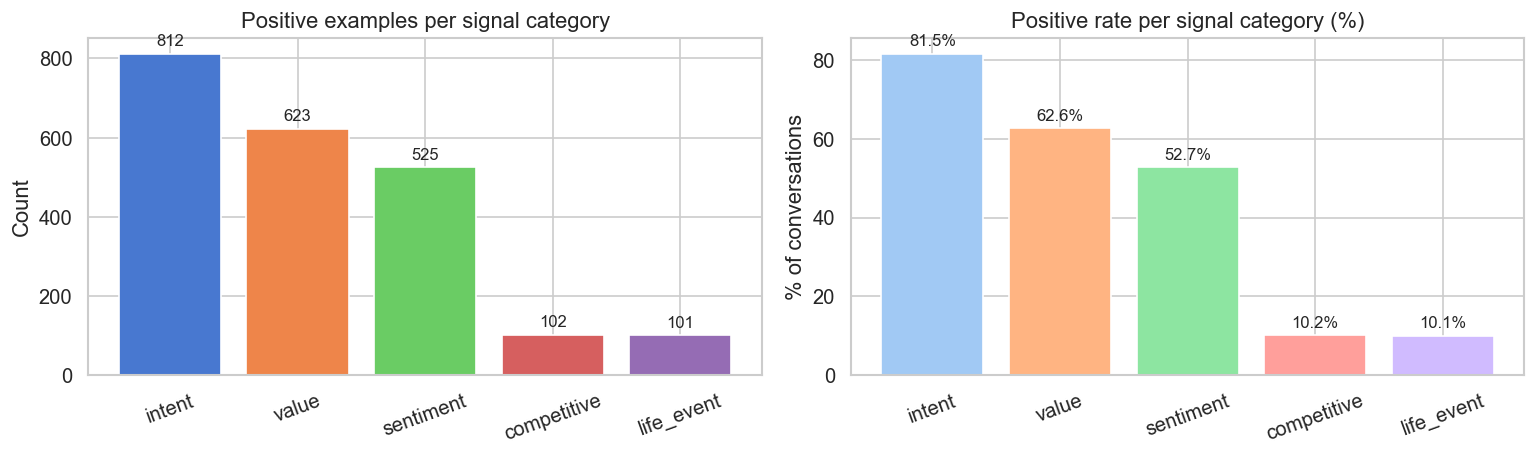

In [7]:
label_counts = df[SIGNAL_CATEGORIES].sum().sort_values(ascending=False)
label_pct = (label_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Absolute counts
ax = axes[0]
bars = ax.bar(label_counts.index, label_counts.values,
              color=sns.color_palette('muted', len(SIGNAL_CATEGORIES)))
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Positive examples per signal category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)

# Percentage
ax2 = axes[1]
bars2 = ax2.bar(label_pct.index, label_pct.values,
                color=sns.color_palette('pastel', len(SIGNAL_CATEGORIES)))
ax2.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=10)
ax2.set_title('Positive rate per signal category (%)')
ax2.set_ylabel('% of conversations')
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'label_distribution.png', bbox_inches='tight')
plt.show()

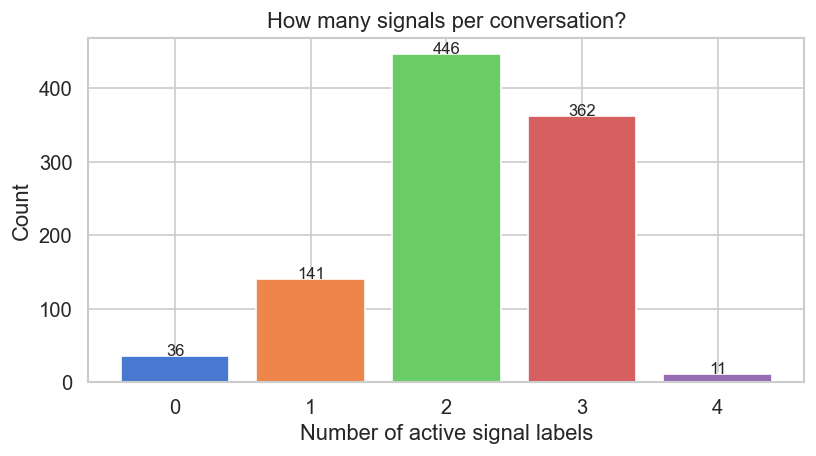

In [8]:
# Breakdown by number of active labels per conversation
label_count_dist = df['n_active_labels'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(label_count_dist.index, label_count_dist.values,
       color=sns.color_palette('muted', len(label_count_dist)))
ax.set_xlabel('Number of active signal labels')
ax.set_ylabel('Count')
ax.set_title('How many signals per conversation?')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for i, v in zip(label_count_dist.index, label_count_dist.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 3 · Signal co-occurrence heatmap

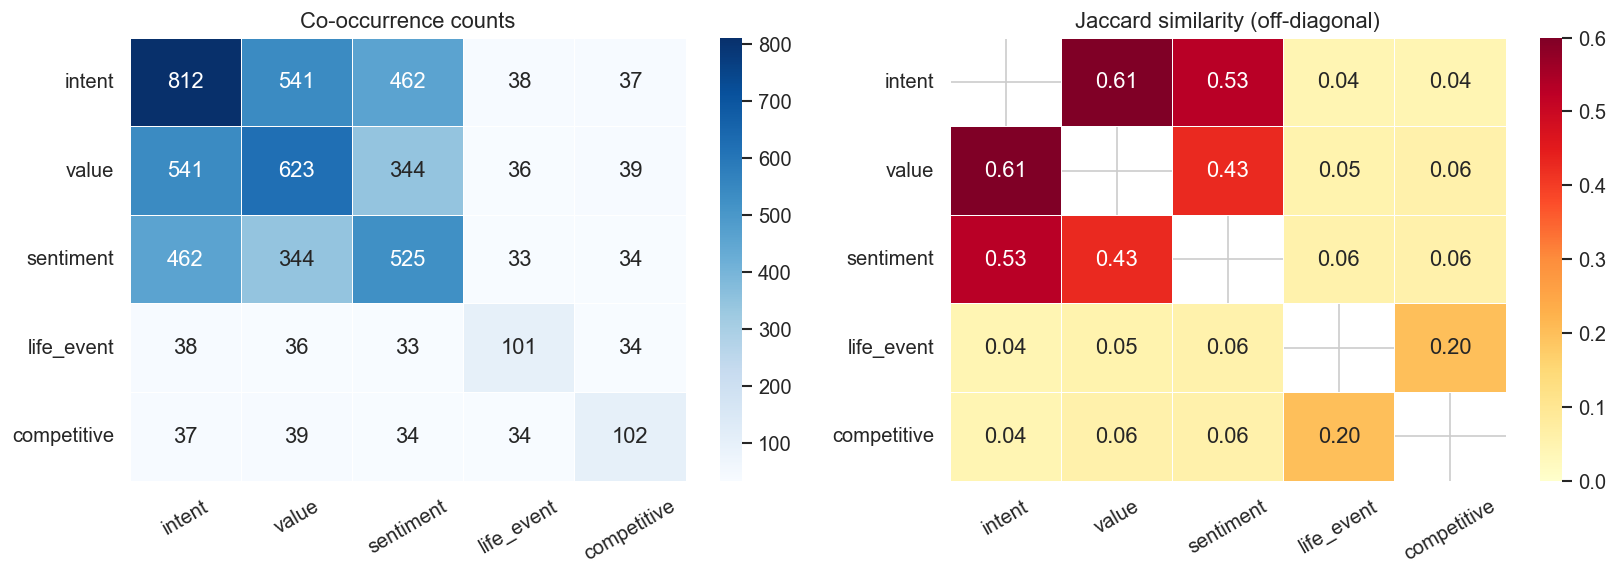

In [9]:
label_matrix = df[SIGNAL_CATEGORIES].values
cooccurrence = (label_matrix.T @ label_matrix).astype(float)

# Normalise by diagonal (Jaccard-style: A∩B / A∪B)
jaccard = np.zeros_like(cooccurrence)
for i in range(len(SIGNAL_CATEGORIES)):
    for j in range(len(SIGNAL_CATEGORIES)):
        union = cooccurrence[i, i] + cooccurrence[j, j] - cooccurrence[i, j]
        jaccard[i, j] = cooccurrence[i, j] / union if union > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cooccurrence, annot=True, fmt='.0f', cmap='Blues',
    xticklabels=SIGNAL_CATEGORIES, yticklabels=SIGNAL_CATEGORIES,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Co-occurrence counts')
axes[0].tick_params(axis='x', rotation=30)

mask = np.eye(len(SIGNAL_CATEGORIES), dtype=bool)
sns.heatmap(
    jaccard, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=SIGNAL_CATEGORIES, yticklabels=SIGNAL_CATEGORIES,
    mask=mask, ax=axes[1], linewidths=0.5, vmin=0, vmax=0.6
)
axes[1].set_title('Jaccard similarity (off-diagonal)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'cooccurrence.png', bbox_inches='tight')
plt.show()

## 4 · Conversation length analysis

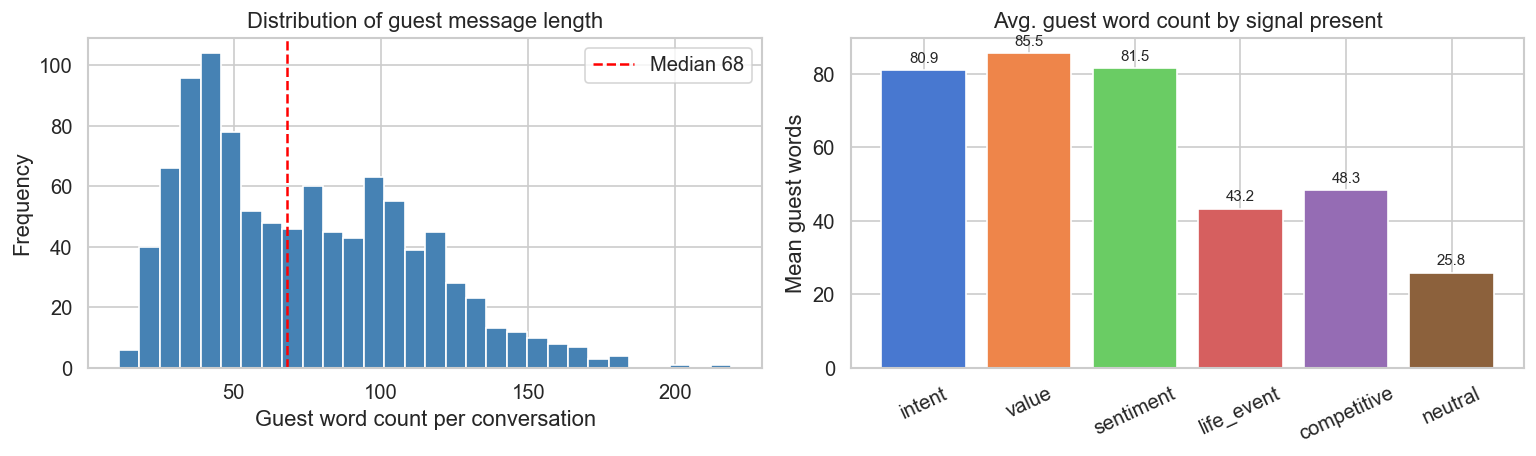

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Word count distribution
ax = axes[0]
ax.hist(df['n_guest_words'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(df['n_guest_words'].median(), color='red', linestyle='--',
           label=f'Median {df["n_guest_words"].median():.0f}')
ax.set_xlabel('Guest word count per conversation')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of guest message length')
ax.legend()

# Mean word count by signal category
ax2 = axes[1]
means = {cat: df[df[cat] == 1]['n_guest_words'].mean() for cat in SIGNAL_CATEGORIES}
means['neutral'] = df[df['n_active_labels'] == 0]['n_guest_words'].mean()
cats = list(means.keys())
vals = list(means.values())
colors = sns.color_palette('muted', len(cats))
bars = ax2.bar(cats, vals, color=colors)
ax2.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax2.set_ylabel('Mean guest words')
ax2.set_title('Avg. guest word count by signal present')
ax2.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## 5 · Keyword frequency per category

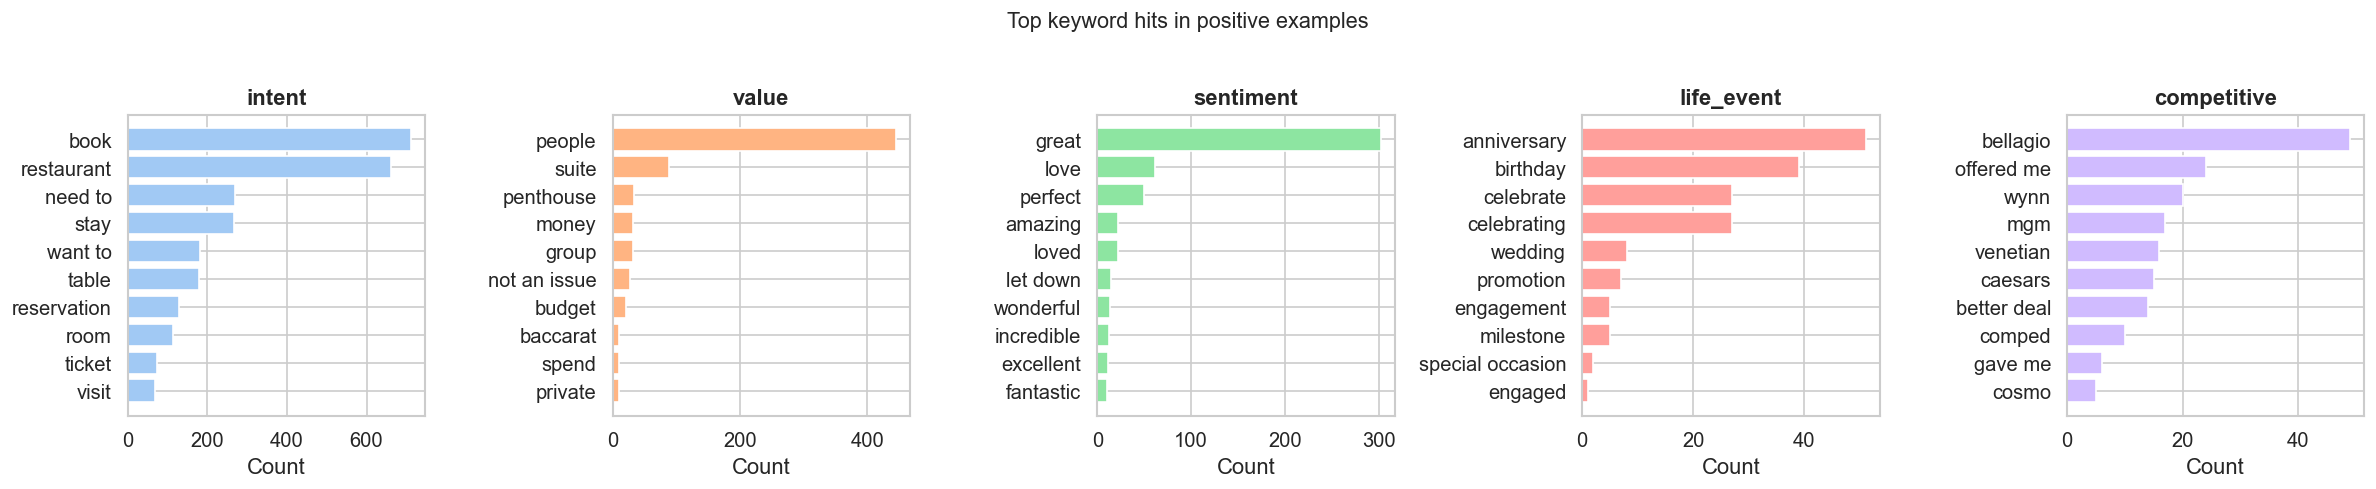

In [11]:
def top_keywords(texts, keywords, top_n=10):
    all_text = ' '.join(texts).lower()
    counts = {kw: all_text.count(kw) for kw in keywords}
    return sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_n]

fig, axes = plt.subplots(1, len(SIGNAL_CATEGORIES), figsize=(20, 4))

for ax, cat in zip(axes, SIGNAL_CATEGORIES):
    pos_texts = df[df[cat] == 1]['guest_text'].tolist()
    if not pos_texts:
        ax.set_title(cat)
        continue
    top = top_keywords(pos_texts, KEYWORD_SIGNALS[cat])
    words, cnts = zip(*top) if top else ([], [])
    ax.barh(list(words)[::-1], list(cnts)[::-1],
            color=sns.color_palette('pastel')[SIGNAL_CATEGORIES.index(cat)])
    ax.set_title(cat, fontweight='bold')
    ax.set_xlabel('Count')

plt.suptitle('Top keyword hits in positive examples', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'processed' / 'keyword_freq.png', bbox_inches='tight')
plt.show()

## 6 · Sample conversations per category

In [12]:
def show_samples(category, n=2):
    """Print n random conversations where the given signal is present."""
    pool = [r for r in records if r['labels'].get(category) == 1]
    import random
    samples = random.sample(pool, min(n, len(pool)))
    for i, r in enumerate(samples, 1):
        print(f'\n--- {category.upper()} sample {i} (id={r["id"]}) ---')
        for msg in r['conversation']:
            role_tag = '👤 Host  ' if msg['role'] == 'host' else '🎲 Guest '
            print(f'  {role_tag}: {msg["content"]}')
        print('  Signals:')
        for sig in r.get('signals', []):
            print(f'    [{sig["category"]}] "{sig["text"]}"  (hint={sig.get("confidence_hint", "?")})' )

for cat in SIGNAL_CATEGORIES:
    show_samples(cat, n=1)


--- INTENT sample 1 (id=mwz_000192) ---
  🎲 Guest : I am looking for a place to stay with free parking and need to be in the north
  👤 Host  : There are several that offer free parking in the north, do you have a price range?
  🎲 Guest : Yes, I'd like a moderately priced one, and I also need free wifi.
  👤 Host  : I have 9 different places for you. Do you prefer a guesthouse or hotel?
  🎲 Guest : I would like a hotel please.
  👤 Host  : Ashley hotel looks like a good choice.
  🎲 Guest : ok i would like to book it for thursday for 2 people for 3 night im also looking for a restaurant in the same price range as the hotel
  👤 Host  : Booking was successful reference number is I53II5MX . There are several restaurants is there any food preference?
  🎲 Guest : Great. I also need to find a restaurant for the same number of people on the same day for 19:00.
  👤 Host  : I'd love to help you find a place to eat. What kind of food do you like, and is there any part of town you prefer to dine in?

## Summary statistics

In [13]:
print('='*50)
print('DATASET SUMMARY')
print('='*50)
print(f'Total conversations : {len(df)}')
print(f'Neutral (0 signals) : {(df["n_active_labels"]==0).sum()}')
print(f'Avg turns/conv      : {df["n_turns"].mean():.1f}')
print(f'Avg guest words     : {df["n_guest_words"].mean():.1f}')
print()
print('Positive rate per category:')
for cat in SIGNAL_CATEGORIES:
    n_pos = df[cat].sum()
    print(f'  {cat:15s}: {n_pos:4d}  ({100*n_pos/len(df):.1f}%)')

DATASET SUMMARY
Total conversations : 996
Neutral (0 signals) : 36
Avg turns/conv      : 12.2
Avg guest words     : 73.5

Positive rate per category:
  intent         :  812  (81.5%)
  value          :  623  (62.6%)
  sentiment      :  525  (52.7%)
  life_event     :  101  (10.1%)
  competitive    :  102  (10.2%)


## 7 - Model diagnostics (AUC-ROC and AUC-PR)

This section reads held-out predictions from `data/processed/final_eval/prediction_table.csv` and plots:

- ROC curves + AUC-ROC per signal
- Precision-Recall curves + AUC-PR per signal

If the file is missing, run `src/final_eval.py` first.

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

pred_path = ROOT / 'data' / 'processed' / 'final_eval' / 'prediction_table.csv'
print(f'Prediction table path: {pred_path}')
print(f'Exists               : {pred_path.exists()}')

if pred_path.exists():
    pred_df = pd.read_csv(pred_path)

    plt.figure(figsize=(8, 5))
    for cat in SIGNAL_CATEGORIES:
        yt_col = f'y_true_{cat}'
        yp_col = f'y_prob_{cat}'
        if yt_col not in pred_df.columns or yp_col not in pred_df.columns:
            continue
        y_true = pred_df[yt_col].astype(int).values
        y_prob = pred_df[yp_col].astype(float).values
        if len(np.unique(y_true)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{cat} (AUC={roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves by Signal')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print('prediction_table.csv not found. Run src/final_eval.py to generate it.')

In [ ]:
if pred_path.exists():
    plt.figure(figsize=(8, 5))
    for cat in SIGNAL_CATEGORIES:
        yt_col = f'y_true_{cat}'
        yp_col = f'y_prob_{cat}'
        if yt_col not in pred_df.columns or yp_col not in pred_df.columns:
            continue
        y_true = pred_df[yt_col].astype(int).values
        y_prob = pred_df[yp_col].astype(float).values
        if len(np.unique(y_true)) < 2:
            continue

        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'{cat} (AUC-PR={pr_auc:.3f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves by Signal')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 8 - Why sentiment can be imbalanced

Yes, this is worth discussing in the report/interview.

Common reasons in this pipeline:

- MultiWOZ hotel/restaurant user turns often contain explicit preference/quality language, which can over-trigger sentiment extraction.
- Synthetic prompts may produce sentiment-rich language more often than neutral operational requests.
- Labeling is LLM-assisted, so borderline polite/neutral wording can drift into positive sentiment.

Recommended framing:

- Report class supports (`support_pos`, `support_neg`) per signal.
- Prefer AUC-PR in addition to F1 when classes are skewed.
- Use source-wise slicing (`multiwoz` vs synthetic) to show where imbalance originates.